<a href="https://colab.research.google.com/github/TeraneAgaeva/python_for_ds_tasks/blob/main/Agaeva_%22HW_2_1_%D0%A2%D0%B5%D1%81%D1%82%D1%83%D0%B2%D0%B0%D0%BD%D0%BD%D1%8F_%D1%81%D1%82%D0%B0%D1%82_%D0%B3%D1%96%D0%BF%D0%BE%D1%82%D0%B5%D0%B7_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Теоретичний блок Z-test

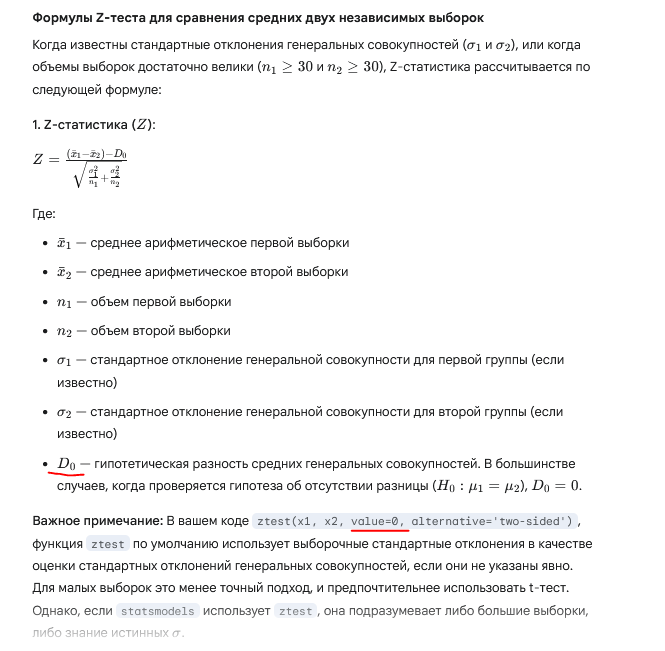

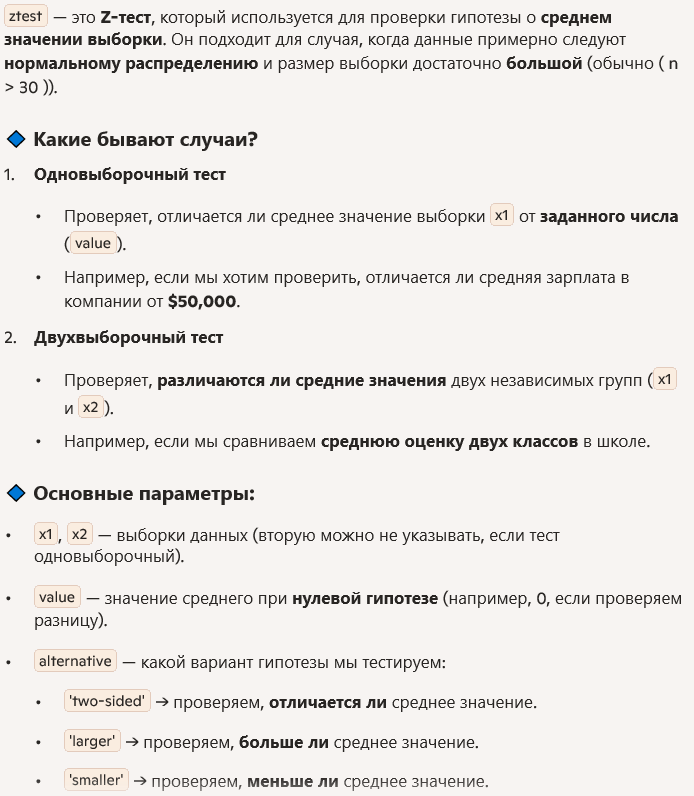

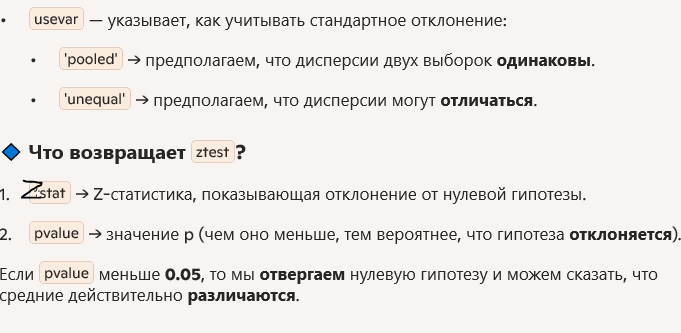

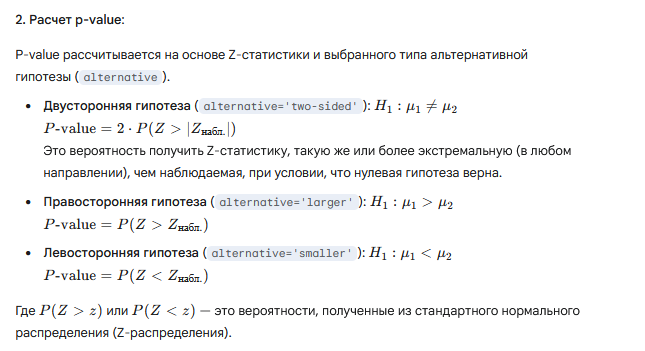

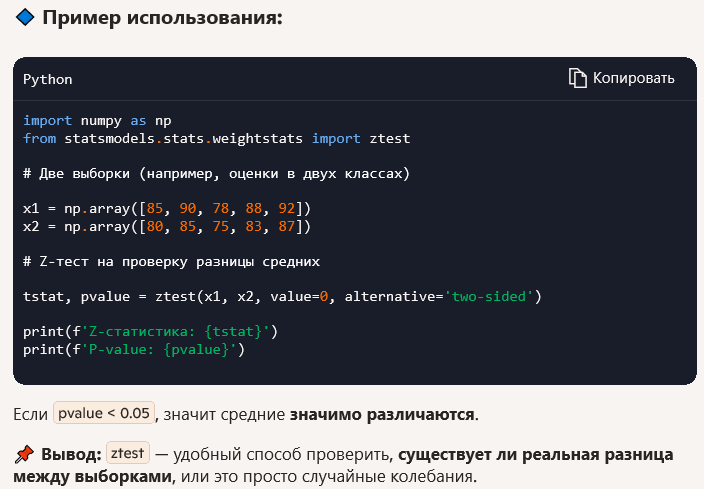

В цьому ДЗ потренуємось виконувати Z-тести для тестування гіпотез в різних задачах. Для коректної імплементації та інтерпретації тестів рекоемндую переглянути спершу документацію:

https://www.statsmodels.org/dev/generated/statsmodels.stats.weightstats.ztest.html

### Завдання 1: Z-тест для однієї вибірки

**Мета**: Перевірити, чи середнє значення вибірки відрізняється від гіпотетичного середнього.

**Припущення**: Середній ріст студентів університету вважається 170 см. Ми хочемо перевірити, чи середній ріст випадкової вибірки студентів істотно більший. Вибірка задана в змінній `heights`.

Для виконання завдання імпортуйте метод для проведення `ztest`, виконайте Z-тест з Python, виведіть p-value і зробіть заключення, чи справдилось припущення про середній зріст студентів на рівні значущості 0.05?

Використовуємо тут Z-тест, оскільки вибірка достатньо велика (більше 30 екземплярів) і можемо вважати, що її стандартне відхилення близьке до ст. відхилення генеральної сукупності, а значить - відоме.

In [ ]:
heights = [174, 171, 175, 179, 170, 170, 179, 175, 169, 174, 169, 169, 173, 162, 163, 169, 166,
           173, 167, 164, 179, 170, 172, 164, 169, 175, 169, 174, 169, 169, 173, 162, 177]

In [ ]:
mean_H0 = 170

In [ ]:
alpha = 0.05  # вірогідність помилки - статистична значущість

In [ ]:
!pip install statsmodels --quiet

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.weightstats import ztest
from math import ceil
from scipy.stats import norm
import scipy.stats as stats
import statsmodels.stats.api as sms
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

In [ ]:
print("Середнє вибірки: {:.2f}".format(np.mean(heights)))
print("Стандартне відхилення вибірки: {:.2f}".format(np.std(heights)))

Середнє вибірки: 170.70
Стандартне відхилення вибірки: 4.65


In [ ]:
ztest_Score, p_value = ztest(heights, value = mean_H0, alternative='larger')    # alternative='larger', адже завдання перевірити чи більший ріст студентів по вибірці відносно генеральної сукупності (тобто всих студентів)

In [ ]:
ztest_Score, p_value

(np.float64(0.8482235371587619), np.float64(0.19815674571091746))

Функція виводить p_value і z-score, що відповідають цьому значенню, ми порівнюємо p-значення з альфа, якщо воно більше альфа, то ми не приймаємо нульову гіпотезу, інакше ми її відхиляємо.

In [ ]:
if(p_value <  alpha):
    print("Відхилити Н0.")
else:
    print("Н0 не може бути відхилена.")

Н0 не може бути відхилена.


**Висновок:** Z-статистика теж демонструє слабке відхилення від Н0. Адже 0,85% це меньше ніж 1,645 (для одностороннього тесту). Адже довірчий інтервал = 95%, тобто 100% - 5% альфа(рівень значущусті - вірогідність помилки) =95%.

Довірчий інтервал 95% означає, що у 95% випадків справжнє значення буде всередині нього. 95% довірчий інтервал = 100% мінус 5% (альфа, статистична значимість – ймовірність помилки). Визначення цих критичних значень (Z) пов'язане зі звичайним розподілом (гаусовим дзвоном). Довірчий інтервал 95% означає, що 95% ймовірності знаходяться в межах певних кордонів, а 5%, що залишилися, розподілені по краях.

Загальні орієнтири:
- Для рівня значущості (alpha = 0.05):
- Односторонній тест: ( Z > 1.645 ) або ( Z < -1.645 )
- Двосторонній тест: (Z > 1.96) (тобто Z більше 1.96 або менше -1.96)

Якщо Z більше 1.645 (для одностороннього тесту), можна сказати, що відхилення від нульової гіпотези значуще лише на рівні ( \alpha = 0.05 ).

🔹 Односторонній тест (Z > 1.645 або Z < -1.645)
- Використовується, коли ми перевіряємо конкретний напрямок зміни.
- Наприклад, якщо ми хочемо перевірити, чи збільшився середній дохід після нового рекламного методу, нас цікавить лише позитивна зміна ((Z > 1.645)).
- Якщо перевіряємо, чи зменшився результат, то беремо (Z<-1.645).

📌 Критичне значення для 95% довірчого інтервалу в односторонньому тесті: 1645, тому що вся ймовірність зосереджена в одній стороні розподілу.

🔹 Двосторонній тест (|Z| > 1.96)
- Використовується, якщо ми хочемо перевірити будь-яке відхилення як у плюс, так і в мінус.
- Наприклад, якщо досліджуємо, чи змінилася середня вага групи після нової дієти (але не знаємо, в який бік).
- Тут важливо дивитися обидві сторони розподілу, тож критичне значення вище – 1.96.

📌 Критичне значення для 95% довірчого інтервалу у двосторонньому тесті: 1.96, тому що ймовірність розподіляється по обидва боки.

🔹 Підсумок
- Якщо важлива конкретна спрямованість ефекту → Односторонній тест ((Z > 1.645)).
- Якщо важлива будь-яка різниця (збільшення або зменшення) → Двосторонній тест ((Z > 1.96)).

Як порахувати показники 1.645 та 1.96?
Ці значення беруться з таблиці стандартного нормального розподілу (або вважаються за допомогою функцій Python).

📌 Односторонній тест:
Ми хочемо перевірити, чи відхиляється середнє в одному напрямку (вгору чи вниз).
- Рівень значимості ( \alpha = 0.05 ) означає, що 5% ймовірності перебувають у хвості (або праворуч, або ліворуч).
- за таблицею нормального розподілу критичне значення для 95% (односторонній тест) → (Z = 1.645).

📌 Двосторонній тест:
Тут ми перевіряємо, чи відрізняється значення будь-якої сторони.
- 5% ймовірності поділяються порівну між двома хвостами (по 2.5% зліва та 2.5% праворуч).
- У таблиці нормального розподілу критичне значення для двостороннього 95% інтервалу → (Z = 1.96).

Підсумок:
- Односторонній тест (Z> 1.645) → перевіряє відхилення в одному напрямку.
- Двосторонній тест (Z > 1.96) → перевіряє відхилення в обидві сторони.
- Довірчий інтервал 95% означає, що у 95% випадків справжнє значення буде всередині нього.

В пайтоне определить критические значения:

from scipy.stats import norm

* Односторонний тест (95%):

z_critical_one_sided = norm.ppf(0.95)

print(f'Критическое значение для одностороннего теста: {z_critical_one_sided:.3f}')

* Двусторонний тест (95%):

 2.5% слева и 2.5% справа

z_critical_two_sided = norm.ppf(0.975)  

print(f'Критическое значение для двустороннего теста: {z_critical_two_sided:.3f}')

```
# Выбран кодовый формат
```







### Завдання 2: Z-тест для двох незалежних вибірок

**Завдання 2.1.**

**Мета**: Перевірити, чи існує статистична різниця між середніми оцінками двох груп студентів.

**Припущення**: Група A отримала новий навчальний курс, а група B продовжувала зі стандартним курсом. Ми перевіряємо, чи є новий курс ефективнішим.

Виконайте Z-тест з Python, виведіть p-value і зробіть заключення, чи справдилось припущення щодо студентів на рівні значущості 0.05?

In [ ]:
group_a_scores = [78.55, 72.25, 79.88, 75.  , 76.54, 74.99, 87.26, 77.93, 72.71,
       82.11, 71.9 , 79.04, 68.2 , 71.36, 78.98, 81.69, 78.86, 77.42,
       76.49, 70.61, 74.4 , 75.7 , 83.29, 79.72, 69.18, 79.62, 76.07,
       74.62, 81.06, 83.15, 82.66, 73.8 , 76.45, 79.66, 82.88, 75.6 ,
       77.07, 72.47, 72.02, 82.06]

group_b_scores = [81.78, 74.64, 80.02, 76.81, 71.77, 76.81, 82.69, 74.82, 82.82,
       61.9 , 79.11, 75.44, 73.5 , 75.46, 65.06, 73.9 , 76.79, 82.39,
       72.41, 70.96, 72.49, 79.58, 76.64, 72.35, 77.57, 75.49, 79.84,
       71.49, 73.36, 73.04, 67.68, 76.48, 76.31, 75.03, 73.83, 67.92,
       72.9 , 73.29, 70.99, 74.19]

In [ ]:
alpha = 0.05       # вірогідність помилки - статистична значущість

# Теоретичний блок A/B - test

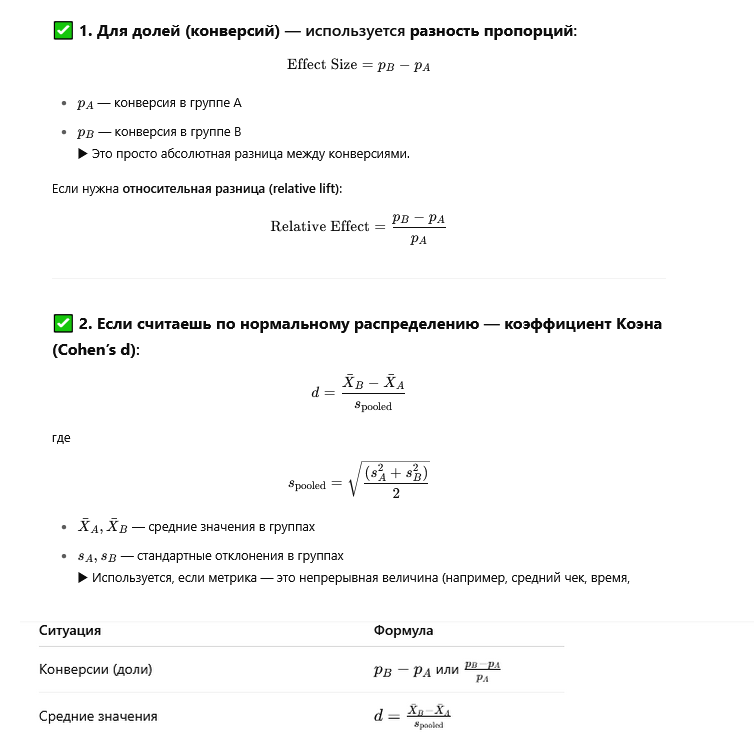

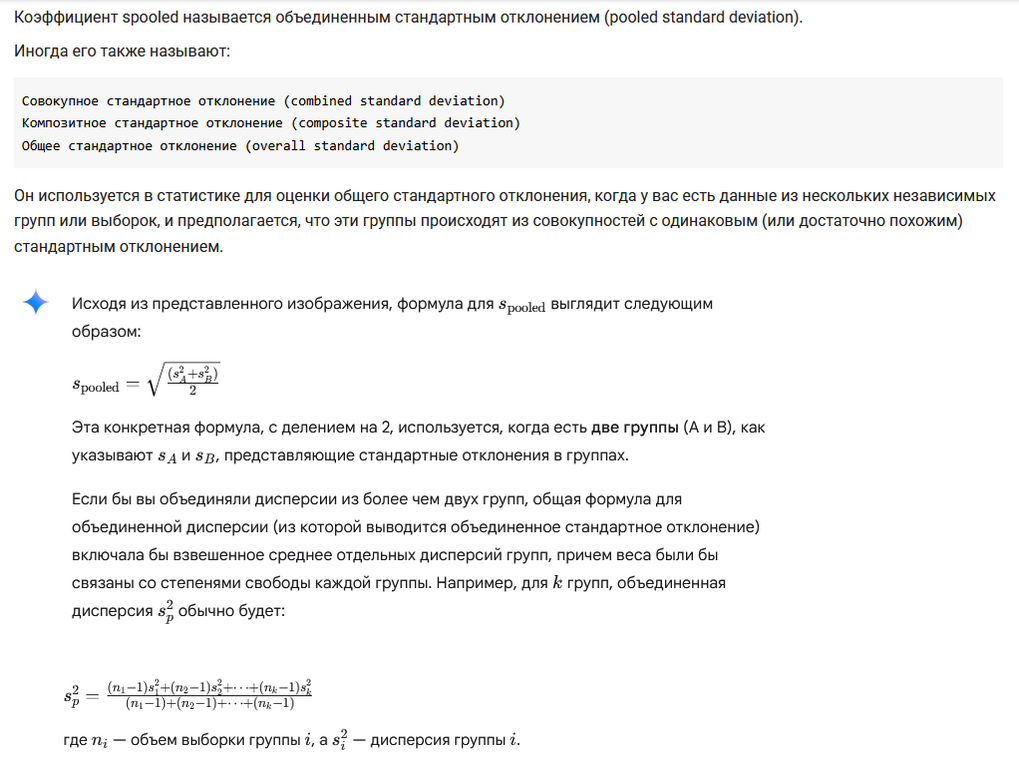

**Рішення 2.1.**

Визначимо довжину вибірок:

In [ ]:
n_A, n_B = (len(group_a_scores), len(group_b_scores))
print(n_A, n_B)

40 40


Розрахуємо середні значення для кожної з двох груп:

In [ ]:
mean_A, mean_B = (np.mean(group_a_scores), np.mean(group_b_scores))
print(mean_A, mean_B)

77.08125 74.73875000000001


Розрахуємо стандартне відхилення для кожної з двох груп:

In [ ]:
std_A, std_B = (np.std(group_a_scores, ddof=1), np.std(group_b_scores, ddof=1))  #ddof=1 використали, адже аналіз двох груп, а не всіх студентів в університеті. Коли аналіз всіх студентів то буде ddof= 0
print(std_A, std_B)

4.36578843438916 4.520769838854599


Розрахуємо варіацію/дисперсію для кожної з двох груп:

In [ ]:
var_A, var_B = (np.var(group_a_scores, ddof=1), np.var(group_b_scores, ddof=1)) #ddof=1 використали, адже аналіз двох груп, а не всіх студентів в університеті. . Коли аналіз всіх студентів то буде ddof= 0
print(var_A, var_B)

19.060108653846157 20.437359935897437


Перевірка розрахунку стандартного відхилення:

In [ ]:
std_A_test, std_B_test = (np.sqrt(var_A), np.sqrt(var_B))
print(std_A_test, std_B_test)

4.36578843438916 4.520769838854599


Розрахуємо - **Коефіцієнт spooled** називається **об'єднане стандартне відхилення (pooled standard deviation)**, щоб використати для розрахунку зміни ефекту по групам.:

In [ ]:
# варіант розрахкунку 1 - більше підходить для t-test:

std_combined  = np.sqrt((np.std(group_a_scores, ddof=1) ** 2 + np.std(group_b_scores, ddof=1) ** 2) / 2)

print(std_combined)


4.443954803423612


In [ ]:
# варіант розрахкунку 2 більше підходить для t-test:

S_pooled = np.sqrt((var_A + var_B)/2)
print(S_pooled)

4.443954803423612


Розрохуємо величину ефекту зміни по формулі **коефіцієнта Коена d** :

In [ ]:
d_effect_size = (mean_A - mean_B)/S_pooled #effect size більше підходить для t-test
print(d)

0.5271205724674182


Якби зміна була у відсотках (пропортція) то могли використати формулу effect_size = sms.proportion_effectsize(proportion1, proportion2) чи 2 * (arcsin(sqrt(prop1)) - arcsin(sqrt(prop2)))

Наприклад, в A/B тестуванні ви можете використовувати sms.proportion_effectsize для розрахунку очікуваного розміру ефекту між конверсією контрольної групи і конверсією нової версії, а потім використовувати цей розмір ефекту для визначення мінімального необхідного розміру вибірки для вашого A/B тесту.

In [ ]:
 # приклад розрахунку
 effect_size = sms.proportion_effectsize(0.15, 0.13)
 print(effect_size)

0.0576728617308947


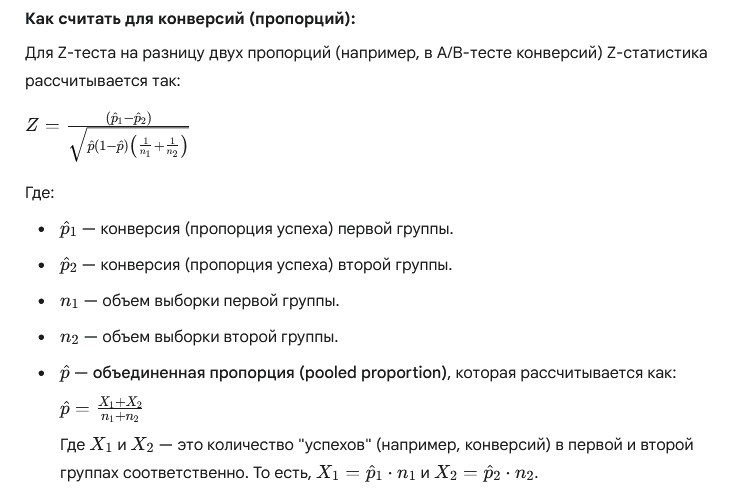

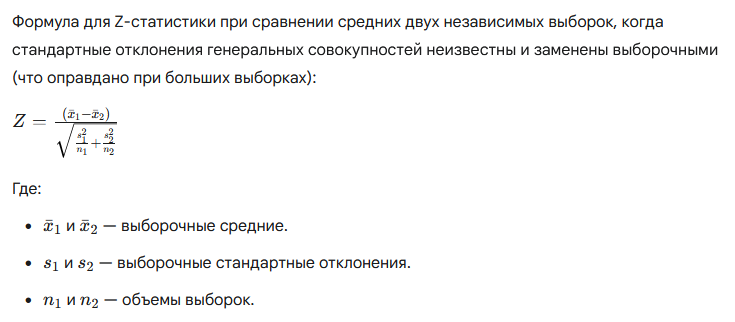

In [ ]:
Z_test = (mean_A - mean_B) /np.sqrt((var_A/n_A)+(var_B/n_B))
print(f"Розрахована Z-статистика: {Z_test:.4f}")

Розрахована Z-статистика: 2.3574


**Розрахунок P-value (для двохсторонього тесту):**

p_value_calculated = 2 * (1 - norm.cdf(abs(z_calculated)))

**Для Правостороннього:**

 Для H1: mu1 > mu2

p_value_one_sided_right = 1 - norm.cdf(z_calculated)

чи

p_value_one_sided_right = norm.sf(z_calculated)

**Для лівостороннього:**

Для H1: mu1 < mu2

p_value_one_sided_left = norm.cdf(z_calculated)

Виходячи з умови "перевіряємо, чи ефективніший новий курс", слід застосовувати правосторонній Z-тест

In [ ]:
z_critical_one_sided = norm.ppf(0.95)
print(z_critical_one_sided)

1.6448536269514722


In [ ]:
p_value_one_sided_right = norm.sf(Z_test)
print(f"Розрахований p_value для правостороннього Zтесту: {p_value_one_sided_right:.4f}")

Розрахований p_value для правостороннього Zтесту: 0.0092


In [ ]:
if(p_value_one_sided_right <  alpha):
    print("Відхилити Н0.")
else:
    print("Н0 не може бути відхилена.")

Відхилити Н0.


# Перевірка та розрахунок Z статистики через statsmodels.stats.weightstats.ztest

In [ ]:
z_statistic, p_value_ztest = ztest(group_a_scores, group_b_scores, value=0, alternative='larger')  #alternative='larger' - для правостороннього тесту, alternative='smaller' - для лівостороннього, alternative='two-sided'- для двостороннього

In [ ]:
print("--- Розрахунок Z-теста за допомогою statsmodels ---")
print(f"Z-статистика: {z_statistic:.4f}")
print(f"P-value: {p_value_ztest:.4f}")

if p_value_ztest < alpha:
    print(f"P-value ({p_value_ztest:.4f}) < alpha ({alpha}), відхиляємо нульову гіпотезу. Існує статистично значуща різниця.")
else:
    print(f"P-value ({p_value_ztest:.4f}) >= alpha ({alpha}), не відхиляємо нульову гіпотезу. Відсутність достатності доказів різниці.")

--- Розрахунок Z-теста за допомогою statsmodels ---
Z-статистика: 2.3574
P-value: 0.0092
P-value (0.0092) < alpha (0.05), відхиляємо нульову гіпотезу. Існує статистично значуща різниця.


**Висновок 2.1.**:

Беручи до уваги результати:

Z-статистика: 2.3574
Рівень статистичної значущості (α): 0.05
Тип тесту: Правосторонній Z-тест (оскільки ми перевіряли, чи є новий курс "ефективнішим")

Щоб зробити висновок, нам потрібно порівняти статистику Z з критичним значенням Z для одностороннього тесту при α=0.05.
Визначення критичного значення:

Для правостороннього Z-тесту з α=0.05, критичне значення Z (Z-критичне) - це значення, при якому 5% площі під кривою стандартного нормального розподілу знаходиться праворуч.

Z-критичне при α=0.05 для правобічного тесту ≈1.645.
Порівняння та висновок:

Порівняння Z-статистики з Z-критичним:
Ваша Z-статистика (2.3574) більша, ніж критичне значення Z (1.645).
2.3574>1.645

Висновок (на основі Z-статистики):
Оскільки Z-статистика, що спостерігається, потрапляє в критичну область (область заперечення нульової гіпотези), ми відкидаємо нульову гіпотезу.

Нульова гіпотеза (H0): Середні оцінки нового курсу (Група A) не вищі або дорівнюють середнім оцінкам стандартного курсу (Група B).
Альтернативна гіпотеза (H1): Середні оцінки нового курсу (Група A) вищі, ніж середні оцінки стандартного курсу (Група B).

Отже, на рівні значущості 0.05 (або 5%) існують достатні статистичні докази того, що новий навчальний курс є більш ефективним, оскільки середні оцінки групи A (новий курс) статистично значно вищі, ніж середні оцінки групи B (стандартний курс).

**Завдання 2.2.**


**Мета**: Побачити, як впливає розмір вибірок на результат тесту.

**Завдання**: Уявіть, що з групи А ми маємо тільки перші 5 записів, а з групи В - усі. Таке могло статись, якщо ми вже маємо результати тестів учнів за попередньою програмою, а тести за новою програмою здали наразі лише 5 учнів і ми вирішили не чекати довше.
Виберіть перші 5 записів для групи А і проведіть t-test (для цього використовуємо наступний [метод](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)). Виведіть значення p-value. Зробіть висновок, який результат ви бачите щодо стат. значущості на рівні 0.05 для цього експерименту?

Тут проводимо t-test оскільки одна з вибірок - дуже мала.

# Теоретичний блок t-test


**Z-тест і t-тест** - це два основні статистичні тести для перевірки гіпотез про середні значення. Їх вибір залежить від кількох ключових факторів: знання стандартного відхилення генеральної сукупності та обсягу вибірки.
Z-тест

**Коли використовується Z-тест:**

*Коли відомо стандартне відхилення генеральної сукупності (σ): Це ідеальний та найсуворіший сценарій для Z-тесту. Якщо ви знаєте справжнє стандартне відхилення всієї сукупності, з якої взяті вибірки, тоді Z-тест є правильним вибором. Насправді це зустрічається рідко (наприклад, під час контролю якості, де історичні дані надають дуже точне σ).

*Коли об'єм вибірки великий (зазвичай n≥30): Це найпоширеніший випадок, коли використовується Z-тест. Згідно з Центральною граничною теоремою, для досить великих вибірок:
Розподіл вибіркових середніх апроксимує нормальний розподіл, незалежно від форми вихідного розподілу генеральної сукупності.
Вибіркове стандартне відхилення (s) стає гарною оцінкою стандартного відхилення генеральної сукупності (σ). Тому навіть якщо справжнє σ невідоме, його можна оцінити за допомогою s, і Z-тест буде досить надійним.

Приклади використання Z-тесту:

Перевірка гіпотези про середній бал за стандартизованим тестом, якщо відомо стандартне відхилення балів по всій країні.
A/B тестування конверсії веб-сайту, якщо у вас дуже великий обсяг трафіку (тисячі і більше спостережень у кожній групі).
Контролює якість у виробництві, де історичні дані дають надійну оцінку мінливості процесу.


**Коли використовується t-тест:**

Коли стандартне відхилення генеральної сукупності (σ) невідоме: Це найпоширеніша ситуація у дослідженнях. Ми майже ніколи не знаємо справжню σ усієї сукупності.

Коли обсяг вибірки малий (n<30): У цьому випадку стандартне вибіркове відхилення (s) може бути неточною оцінкою σ. Тому замість нормального розподілу для оцінки використовується t-розподіл Стьюдента, який має "важчі хвости" і краще враховує невизначеність, пов'язану з оцінкою σ за малою вибіркою.

Важливе зауваження про t-тест та об'єднану дисперсію:
Коли ви порівнюєте середні дві незалежні вибірки за допомогою t-тесту, є два основні варіанти:

**t-тест для рівних дисперсій (pooled t-test):** Використовується, коли передбачається, що дисперсії двох генеральних сукупностей рівні. У цьому випадку для розрахунку стандартної помилки використовується об'єднане стандартне відхилення (spooled).

**t-тест Уелча (Welch's t-test):** Використовується, коли дисперсії двох генеральних сукупностей передбачаються нерівними. Це більш робастний варіант, який не вимагає припущення про рівність дисперсій і часто рекомендується як варіант за умовчанням, якщо немає вагомих причин припускати рівність.

Приклади використання t-тесту:

Порівняння середнього рівня кров'яного тиску у двох невеликих групах пацієнтів, які отримали різне лікування.
Оцінка, чи впливає новий метод навчання на середній бал невеликої групи студентів, порівняно з контрольною групою.
Порівняння середньої прибутковості двох різних інвестиційних портфелів за короткий період.

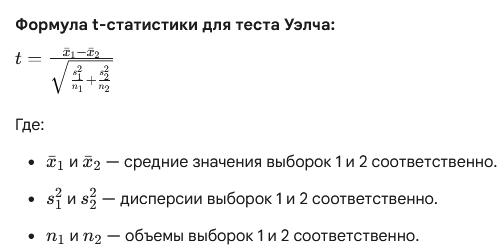

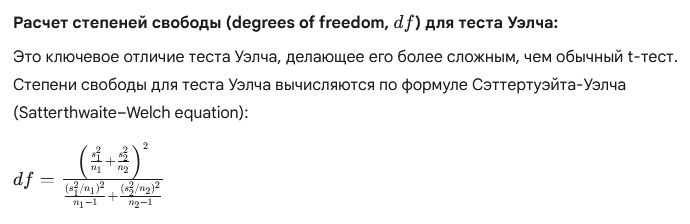

**Рішення 2.2.**

In [ ]:
group_a_scores_5 = group_a_scores[:5]

print(group_a_scores_5)

[78.55, 72.25, 79.88, 75.0, 76.54]


In [ ]:
n_A_5, n_B = (len(group_a_scores_5 ), len(group_b_scores))
print(n_A_5, n_B)

5 40


In [ ]:
alpha = 0.05  # вірогідність помилки - статистична значущість

In [ ]:
mean_A_5, mean_B = (np.mean(group_a_scores_5), np.mean(group_b_scores))
print(mean_A, mean_B)

77.08125 74.73875000000001


In [ ]:
var_A_5, var_B = (np.var(group_a_scores_5, ddof=1), np.var(group_b_scores, ddof=1)) #ddof=1 використали, адже аналіз двох груп, а не всіх студентів в університеті. . Коли аналіз всіх студентів то буде ddof= 0
print(var_A_5, var_B)

8.981329999999991 20.437359935897437


In [ ]:
t_test = (mean_A_5 - mean_B) /np.sqrt((var_A_5/n_A_5)+(var_B/n_B))
print(f"Розрахована T-статистика: {t_test:.4f}")

Розрахована T-статистика: 1.1227


In [ ]:
df_welch = (((var_A_5/n_A_5)+(var_B/n_B))**2)/((((var_A_5/n_A_5)**2)/(n_A_5-1))+(((var_B/n_B)**2)/(n_B-1)))
print(df_welch)

6.544857383782639


In [ ]:
t_statistic, p_value_ttest = stats.ttest_ind(group_a_scores_5, group_b_scores, equal_var=False, alternative='greater')

print(f"t-статистика Уелча: {t_statistic:.4f}")
print(f"P-value Уелча: {p_value_ttest:.4f}")

t-статистика Уелча: 1.1227
P-value Уелча: 0.1505


In [ ]:
if p_value_ttest < alpha:
    print(f"P-value ({p_value_ttest:.4f}) < alpha ({alpha}), відхиляємо нульову гіпотезу. Існує статистично значуща різниця.")
else:
    print(f"P-value ({p_value_ttest:.4f}) >= alpha ({alpha}), не відхиляємо нульову гіпотезу. Відсутність достатності доказів різниці.")

P-value (0.1505) >= alpha (0.05), не відхиляємо нульову гіпотезу. Відсутність достатності доказів різниці.


**Висновок 2.2.:** Немає достатніх статистичних доказів на рівні значущості 0.05, щоб стверджувати, що новий навчальний курс є більш ефективним. Спостережувана різниця 1.1227 в середніх оцінках між групою A (новий курс) та групою B (стандартний курс) не є статистично значущою. Ця різниця 1.1227 може бути результатом випадковості, а не реального ефекту нового курсу.


### Завдання 3\*: Z-тест для двох **пов'язаних** вибірок

**Мета**: Перевірити, чи вплинув тренінг на продуктивність працівників, коли всі справробітники проходили тренінг.

**Припущення**: Наші працівники проходять однаковий тренінг, і ми хочемо з'ясувати, чи покращилися їхні показники після тренінгу на рівні значущості 0.05. Виконайте Z-тест з Python, виведіть p-value і зробіть заключення, чи поліпшились показники працівників на рівні значущості 0.05?

Зверніть увагу, ці вибірки повʼязані між собою, значить не буде коректно виконати z-test між ними, натомість, ми можемо порівняти, чи різниця в результатах (продуктивності співробітників) є стат значущою.

In [ ]:
before_training = [57.82, 37.63, 36.8 , 55.22, 52.97, 52.5 , 53.46, 43.2 , 52.32,
       52.93, 42.86, 68.66, 54.74, 38.09, 56.57, 40.25, 57.87, 61.59,
       41.79, 59.63, 54.13, 58.22, 68.97, 47.55, 42.46, 41.1 , 41.84,
       49.23, 53.41, 52.77]

after_training = [62.47, 40.66, 42.7 , 57.69, 61.41, 56.76, 54.75, 44.06, 56.29,
       55.48, 47.28, 72.6 , 57.59, 39.39, 56.54, 42.36, 62.58, 65.01,
       42.3 , 62.98, 57.9 , 59.45, 72.28, 50.66, 43.18, 44.82, 45.96,
       54.4 , 58.52, 53.01]

In [ ]:
n_before, n_after = (len(before_training), len(after_training))
print(n_before, n_after )

30 30


In [ ]:
z_statistic_before_after, p_value_ztest_before_after = ztest(before_training, after_training, value=0, alternative='larger')

In [ ]:
if p_value_ztest_before_after < alpha:
    print(f"P-value ({p_value_ztest_before_after:.4f}) < alpha ({alpha}), відхиляємо нульову гіпотезу. Існує статистично значуща різниця.")
else:
    print(f"P-value ({p_value_ztest_before_after:.4f}) >= alpha ({alpha}), не відхиляємо нульову гіпотезу. Відсутність достатності доказів різниці.")

P-value (0.9142) >= alpha (0.05), не відхиляємо нульову гіпотезу. Відсутність достатності доказів різниці.


In [ ]:
t_statistic, p_value_T = stats.ttest_rel(after_training, before_training, alternative='greater')

In [ ]:
print(f"P-value_: {p_value_T :.4f}")

P-value_: 0.0000


**Висновок 3.:** z-test та t-test дали різні значення p_value. При цьому в  z-test p_value високий та дорівнює 0.9142, що більше статистичної значущості 0.05, та говорить про те, що не можна відкидати Н0, тобто після навчання суттєво ефективність не збільшилась. В t-test p_value =0, що навпаки вказує на те, що тренінг суттєво впринув на подуктивність працівників і потрібно відкидати гіпотезу Н0 та приймати альтернативну гіпотезу. Тобто два тести дали абсолютно протилежні висновки, що вимагає додаткового аналізу.

Коли ті самі співробітники проходять тест до і після тренінгу, їх показники "до" і "після" не є незалежними. Результат однієї людини "після" тренінгу тісно пов'язаний з її ж результатом "до" тренінгу. Ігнорування цієї залежності (як це робить ztest для незалежних вибірок) призводить до неправильно завищеної оцінки стандартної помилки та помилково високої P-value.

Парний t-тест спеціально розроблений для таких ситуацій, ефективно контролюючи індивідуальні відмінності між учасниками, дозволяючи більш точно оцінити ефект втручання (тренінгу).

Отже висновок на основі t-тесту (P-value близько 0) є правильним. Він вказує на те, що тренінг справді справив статистично значущий позитивний вплив на продуктивність працівників.